Task : Implement ML model on diabetes data and predict pateint diabetes level.
Domain: healthcare

Step 1: import necessary libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

step 2: Load diabetes data file and store it in dataframe db

In [2]:
db=pd.read_csv("diabetes.xls")

Step 3: display dataframe

In [3]:
db

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In this historical data The target variable is Glucose (Labelled) based on task
Target variable (Glucose) has a continuous data, Regression ML model can be applied.

Step 4. Data preprocessing

In [4]:
#4.1 : display top 5 records:
db.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
db.ndim

2

In [6]:
db.shape

(768, 9)

In [7]:
db.size

6912

In [8]:
db.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [9]:
db.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
print(db.duplicated().sum())

0


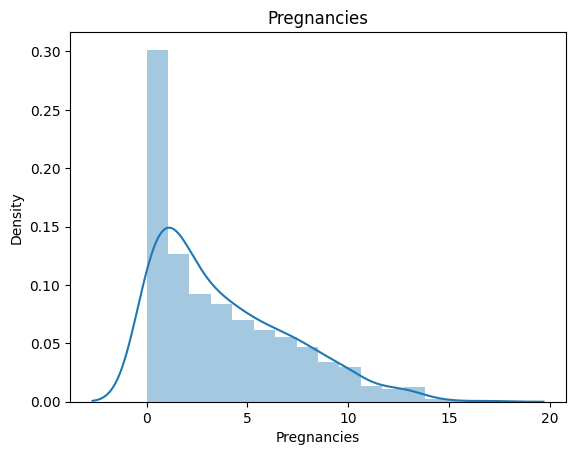

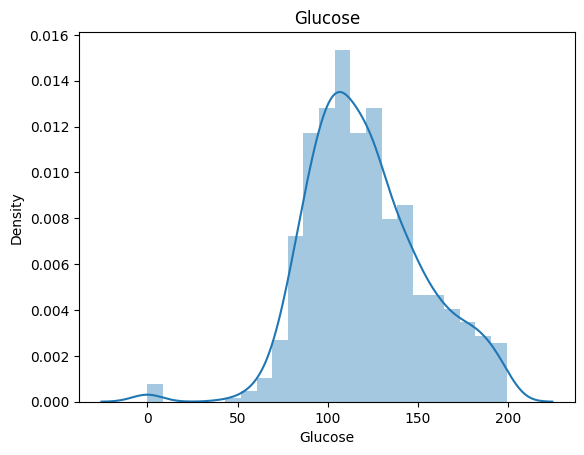

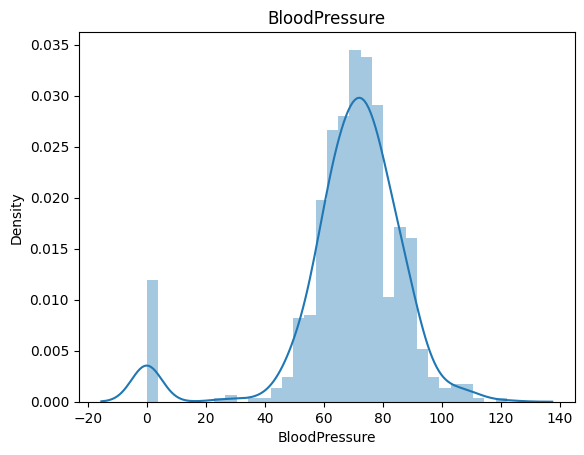

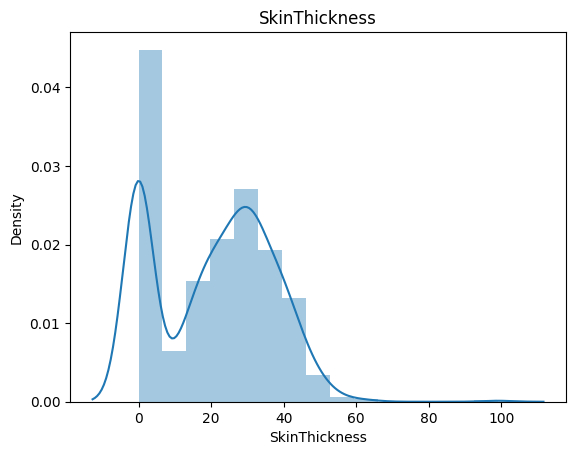

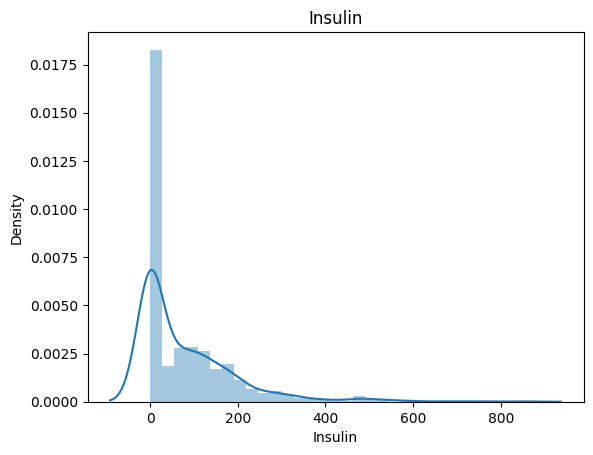

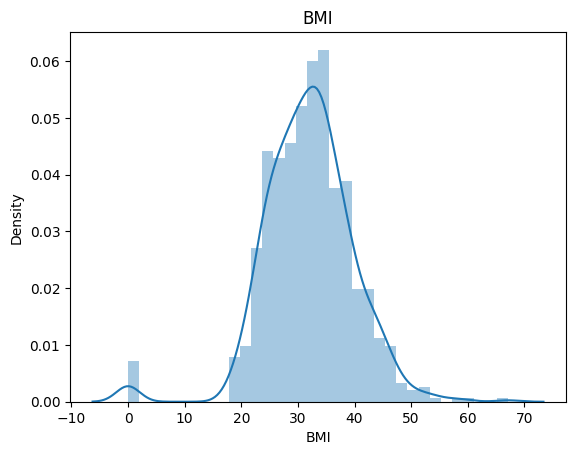

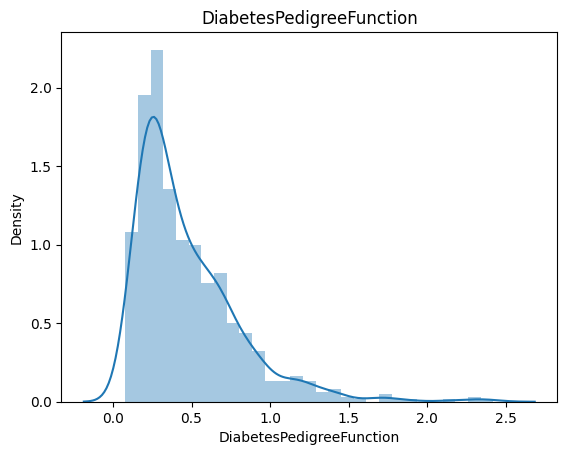

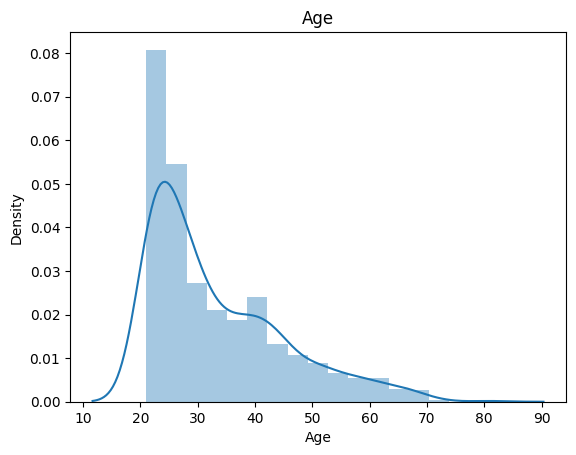

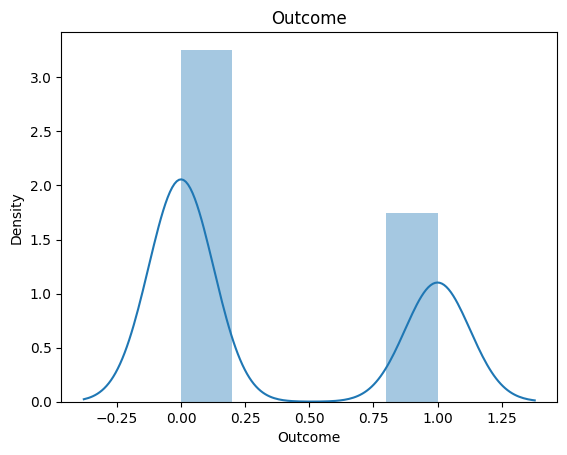

In [12]:
# Display distribution of variables (normal distribution=bell curve)
for i in db.columns:
    if(db[i].dtype!='object'):
        sns.distplot(db[i])
        plt.title(i)
        plt.show()

In [14]:
#display statistical measures of numeric columns
db.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [15]:
#drop outcome column
db=db.drop('Outcome',axis=1)
db.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


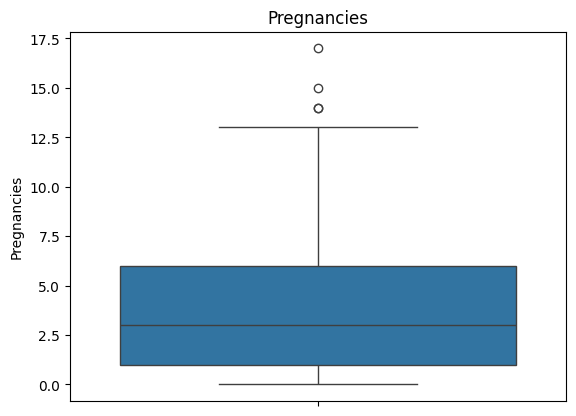

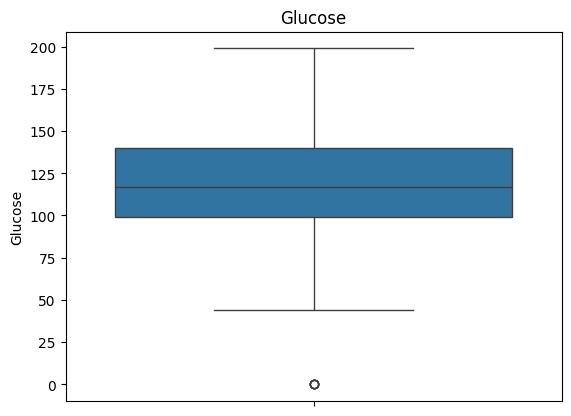

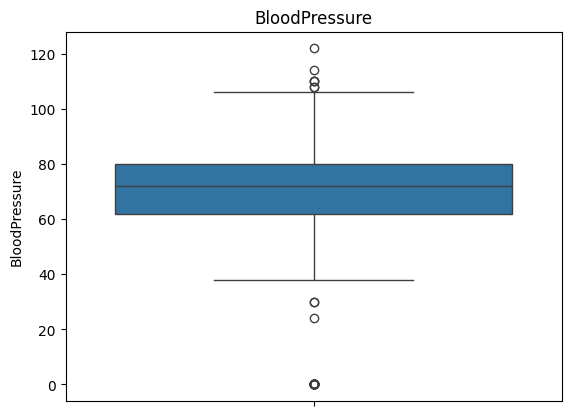

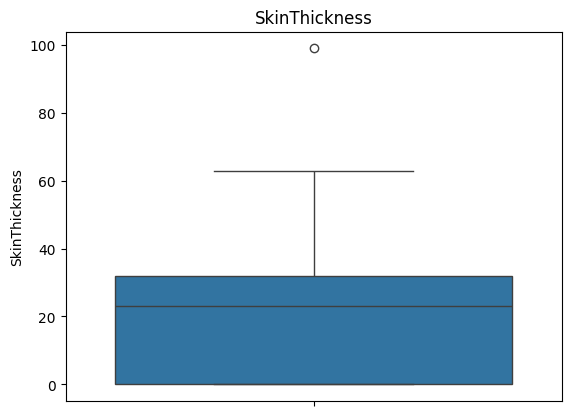

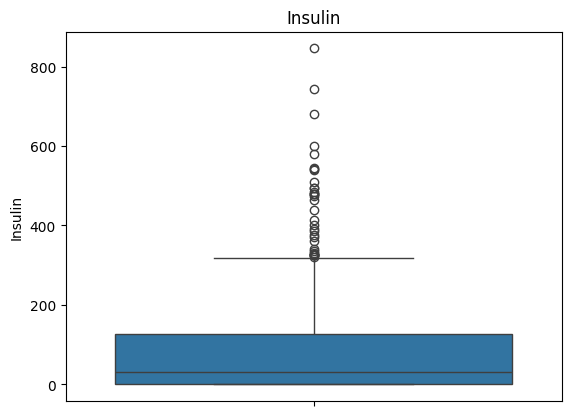

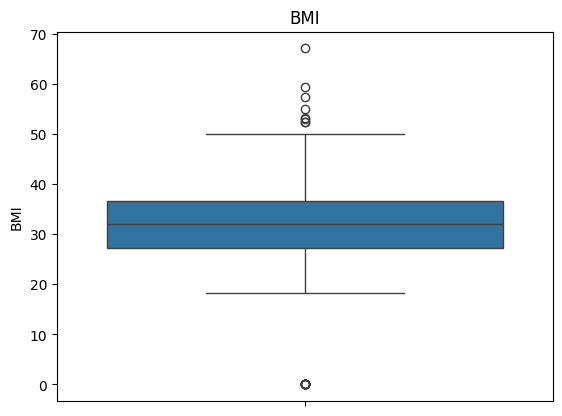

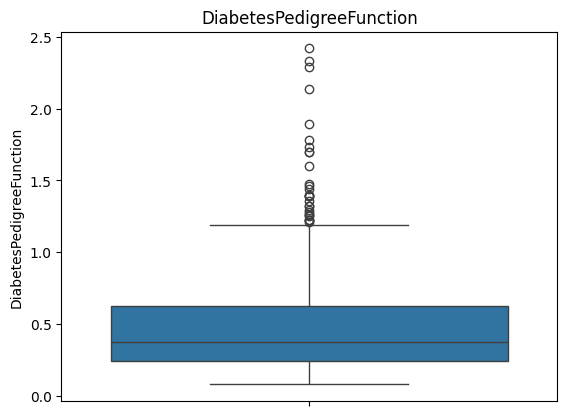

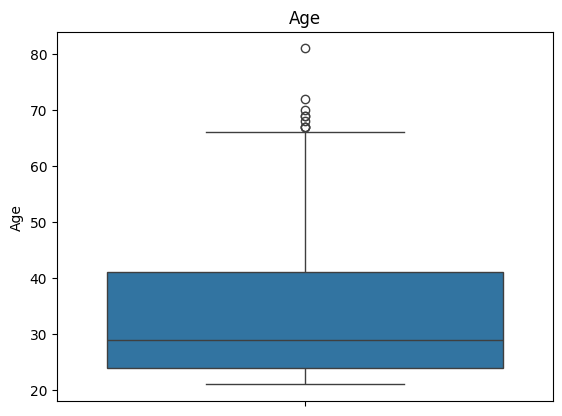

In [16]:
#checking outliers
for i in db.columns:
    if(db[i].dtype!='object'):
        sns.boxplot(db[i])
        plt.title(i)
        plt.show()

In [21]:
#remove outliers:

for i in db.columns:
    q1=db[i].quantile(0.25)
    q3=db[i].quantile(0.75)
    iqr=q3-q1
    lb=q1-1.5*iqr
    ub=q3+1.5*iqr
    db=db[(db[i]>=lb) & (db[i]<=ub)]

In [ ]:
#since all features are numeric , no encoding is required.

In [ ]:
#no scalling required

Split or divide data frame into independent features(x) and dependent feature(y,target variable)

In [23]:
x=db.drop("Glucose",axis=1)
y=db["Glucose"]

Split data into train and test data

In [38]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.8,random_state=42)
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test:",y_test.shape)

x_train shape: (461, 7)
x_test shape: (116, 7)
y_train shape: (461,)
y_test: (116,)


step 5: Apply Linear regression ML model

In [25]:
from sklearn.linear_model import LinearRegression

In [26]:
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


6. Test model

In [28]:
y_pred=model.predict(x_test)

7.Display actual output and model output

In [31]:
res=pd.DataFrame()
res['Actual glucose']=y_test
res['Predicted glucose']=y_pred
res['error']=y_test-y_pred
res['square of error']=(y_test-y_pred)**2
res

,Actual glucose,Predicted glucose,error,square of error
162,114,147.223831,-33.223831,1103.822922
527,116,118.234088,-2.234088,4.991147
688,140,117.324880,22.675120,514.161055
136,100,104.098474,-4.098474,16.797489
580,151,105.687145,45.312855,2053.254806
...,...,...,...,...
277,104,111.104406,-7.104406,50.472591
102,125,110.544817,14.455183,208.952328
322,124,104.487549,19.512451,380.735745
329,105,115.687116,-10.687116,114.214448


Step 8: Performace evaluation of linear regression ML model. 
i) plot the regression response 
ii) quantitative measures (MSE,MAE,RMSE,R2_score)

 i) plot the regression response

In [32]:
p1=min(min(y_test),min(y_pred))
p2=max(max(y_test),max(y_pred))

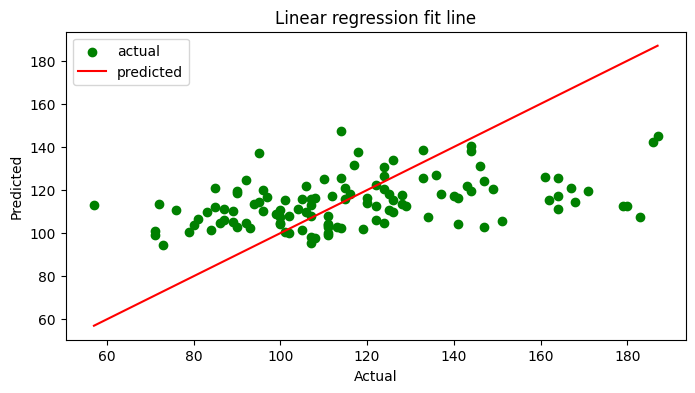

In [33]:
plt.figure(figsize=(8,4))
plt.scatter(y_test,y_pred,color='green',label='actual')
plt.plot([p1,p2],[p1,p2],color='red',label='predicted')
plt.legend()
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear regression fit line")
plt.show()

ii) quantitative measures (MSE,MAE,RMSE,R2_score)

In [34]:
from sklearn.metrics import *

In [35]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2_score=r2_score(y_test,y_pred)

In [36]:
print("Mean square error(MSE):",mse)
print("Mean absolute error(MAE):",mae)
print("Root mean square error(RMSE):",rmse)
print("R2 score:",r2_score)

Mean square error(MSE): 644.4203860488757
Mean absolute error(MAE): 19.818949668732646
Root mean square error(RMSE): 25.38543649514177
R2 score: 0.1652093061160167
